# Double Post-LASSO Regression
## Causal Effect of Scholarship on Student Dropout

### PICO Framework

| Component | Description |
|-----------|-------------|
| **Population** | Higher education students from Portugal |
| **Intervention** | Being a scholarship holder |
| **Control** | Students without scholarship, with similar socio-demographic & academic characteristics |
| **Outcome** | Dropout (binary: 1 = Dropout, 0 = Enrolled/Graduate) |

**Hypothesis:** Receiving a scholarship has a **negative** effect on the probability of dropout.

---

### Methodological Rationale — Why Double Post-LASSO?

The causal DAG reveals a high-dimensional confounding structure: socio-demographic, academic, and macroeconomic variables all confound the `Scholarship holder → Dropout` path.

**Double Post-LASSO** (Belloni, Chernozhukov & Hansen, 2014) solves the variable selection problem in a way that is valid for causal inference:

1. LASSO of **Treatment** on controls → $S_T$ (variables that predict scholarship)
2. LASSO of **Outcome** on controls → $S_Y$ (variables that predict dropout)
3. **Union** $S = S_T \cup S_Y$ as the control set
4. **OLS** of Outcome on Treatment + $S$ → unbiased $\hat{\beta}_T$

This avoids the omitted-variable bias of manual selection and the post-selection inference problem of a single LASSO.

> **DAG constraint:** `Debtor` and `Tuition fees up to date` are **mediators** on the path Scholarship → Financial Constraints → Dropout. They are excluded from all control sets to avoid post-treatment bias.

## 1. Imports

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

## 2. Data Loading & Preprocessing
### Data loading and definition of the target variable

In [107]:
df = pd.read_csv('data.csv', sep=';')

# Strip trailing whitespace/tabs from column names (artefact of the raw dataset)
df.columns = df.columns.str.strip()

# Binarize outcome: 1 = Dropout, 0 = Enrolled or Graduate
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print(f"Dataset shape : {df.shape}")

Dataset shape : (4424, 38)


### Definition of the other variables

We define three groups of controls based on the DAG:
- **Socio-demographic**: confound both scholarship assignment and dropout risk
- **Academic**: predict dropout; some also predict scholarship eligibility  
- **Macroeconomic**: affect scholarship availability and dropout risk

**Excluded mediators**: `Debtor` and `Tuition fees up to date` lie on the causal path  
Scholarship → Financial Constraints → Dropout. Including them would block part of the indirect effect.

In [108]:
treatment = 'Scholarship holder'
outcome   = 'dropout'

socio_demo = [
    'Marital status',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation",    "Father's occupation",
    'Nacionality', 'Gender', 'Age at enrollment',
    'Displaced', 'Educational special needs', 'International',
]

academic = [
    'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance',
    'Previous qualification', 'Previous qualification (grade)',
    'Admission grade',
    'Curricular units 1st sem (credited)',   'Curricular units 2nd sem (credited)',
    'Curricular units 1st sem (enrolled)',   'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (evaluations)','Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (approved)',   'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',      'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (without evaluations)',
]

macro = ['Unemployment rate', 'Inflation rate', 'GDP']

# EXCLUDED mediators: ['Debtor', 'Tuition fees up to date']

all_controls = socio_demo + academic + macro

### Feature Engineering : one hot encoding for categorical variables

**Key choices:**
- Categorical variables with many levels (Course, Application mode, etc.) are one-hot encoded with `drop_first=True` to avoid perfect multicollinearity.
- Variables that are already binary or ordinal are left as-is.
- All features are standardised (mean 0, std 1) before LASSO to ensure penalisation is applied equally across variables.

In [109]:
# Select working sample
cols_needed = [treatment, outcome] + all_controls
data = df[cols_needed].dropna().copy()
data = data.reset_index(drop=True)

# Covariates
X_raw = data[all_controls].copy()
# Treatment
T = data[treatment].values.astype(float)
# Outcomes
Y = data[outcome].values.astype(float)

# one-hot encoding for categorical variables
# variables to encode
categorical_cols = [
    'Marital status',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation",    "Father's occupation",
    'Nacionality', 'Application mode', 'Application order', 'Course',
]
X_raw[categorical_cols] = X_raw[categorical_cols].astype('category')

X_enc = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
print(f"Shape after one-hot encoding: {X_enc.shape}")


Shape after one-hot encoding: (4424, 226)


### Standardisation of the data set

In [110]:
# Standardise
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X_enc)
X_scaled_df  = pd.DataFrame(X_scaled_arr, columns=X_enc.columns)

### Clean of the dataset

In [111]:
# Drop near-zero-variance columns (would cause singular matrices in logit)
var_mask = X_scaled_df.var() > 1e-6
dropped_cols = X_scaled_df.columns[~var_mask].tolist()
if dropped_cols:
    print(f"Dropped {len(dropped_cols)} near-zero-variance columns: {dropped_cols}")
X_scaled_df = X_scaled_df.loc[:, var_mask]

# Also remove perfectly collinear columns via correlation matrix
corr_matrix = X_scaled_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.999)]
if to_drop_corr:
    print(f"Dropped {len(to_drop_corr)} perfectly collinear columns: {to_drop_corr}")
    X_scaled_df = X_scaled_df.drop(columns=to_drop_corr)

X_scaled     = X_scaled_df.values
feature_names = X_scaled_df.columns.tolist()

print(f"Final feature matrix: {X_scaled.shape[0]} obs × {X_scaled.shape[1]} features")

Dropped 2 perfectly collinear columns: ["Father's qualification_18", "Father's occupation_124"]
Final feature matrix: 4424 obs × 224 features


## 3. Double Post-LASSO with Belloni formula

We implement the **Belloni et al. (2014) plug-in penalty**:

$$\alpha = c \cdot \hat{\sigma} \cdot \sqrt{\frac{\log(p)}{n}}$$

where:
- $c = 1.1$ (recommended constant)
- $\hat{\sigma}$ is estimated from the OLS residuals of each first-stage regression
- $p$ = number of features, $n$ = number of observations

### Calculation of $\alpha$

In [112]:
from sklearn.linear_model import Lasso

n, p = X_scaled.shape
c = 1.1  # Belloni recommended constant

def belloni_alpha(X, y, c, n, p):
    """Compute plug-in Belloni alpha: c * sigma_hat * sqrt(log(p)/n)."""
    ols_coef, _, _, _ = np.linalg.lstsq(np.c_[np.ones(n), X], y, rcond=None)
    residuals = y - np.c_[np.ones(n), X] @ ols_coef
    sigma_hat = np.std(residuals, ddof=p + 1)
    return c * sigma_hat * np.sqrt(np.log(p) / n), sigma_hat

### Step 1: LASSO(T ~ X)

In [113]:
alpha_T, sigma_T = belloni_alpha(X_scaled, T, c, n, p)
print(f"  n={n}, p={p} | sigma_T={sigma_T:.4f} | alpha_T={alpha_T:.6f}")

lasso_T = Lasso(alpha=alpha_T, max_iter=20000, fit_intercept=True)
lasso_T.fit(X_scaled, T)

coef_T      = lasso_T.coef_
selected_T  = [feature_names[i] for i in np.where(coef_T != 0)[0]]
print(f"  → {len(selected_T)} / {p} variables selected\n")
for v in selected_T:
    print(f"     • {v:55s} coef = {coef_T[feature_names.index(v)]:+.4f}")

  n=4424, p=224 | sigma_T=0.3905 | alpha_T=0.015024
  → 29 / 224 variables selected

     • Gender                                                  coef = -0.0258
     • Age at enrollment                                       coef = -0.0366
     • Previous qualification (grade)                          coef = +0.0003
     • Curricular units 1st sem (credited)                     coef = -0.0313
     • Curricular units 2nd sem (credited)                     coef = -0.0123
     • Curricular units 1st sem (evaluations)                  coef = -0.0240
     • Curricular units 2nd sem (approved)                     coef = +0.0900
     • Unemployment rate                                       coef = +0.0101
     • Marital status_2                                        coef = -0.0038
     • Mother's qualification_3                                coef = -0.0232
     • Mother's qualification_4                                coef = -0.0056
     • Father's qualification_3                          

### Step 2: LASSO(Y ~ X)

In [114]:
alpha_Y, sigma_Y = belloni_alpha(X_scaled, Y, c, n, p)
print(f"  n={n}, p={p} | sigma_Y={sigma_Y:.4f} | alpha_Y={alpha_Y:.6f}")

lasso_Y = Lasso(alpha=alpha_Y, max_iter=20000, fit_intercept=True)
lasso_Y.fit(X_scaled, Y)

coef_Y      = lasso_Y.coef_
selected_Y  = [feature_names[i] for i in np.where(coef_Y != 0)[0]]
print(f"  → {len(selected_Y)} / {p} variables selected\n")
for v in selected_Y:
    print(f"     • {v:55s} coef = {coef_Y[feature_names.index(v)]:+.4f}")

  n=4424, p=224 | sigma_Y=0.3245 | alpha_Y=0.012485
  → 25 / 224 variables selected

     • Gender                                                  coef = +0.0113
     • Age at enrollment                                       coef = +0.0297
     • Curricular units 1st sem (credited)                     coef = +0.0050
     • Curricular units 2nd sem (credited)                     coef = +0.0438
     • Curricular units 2nd sem (enrolled)                     coef = +0.1398
     • Curricular units 1st sem (approved)                     coef = -0.0286
     • Curricular units 2nd sem (approved)                     coef = -0.2953
     • Curricular units 2nd sem (grade)                        coef = -0.0601
     • Unemployment rate                                       coef = +0.0030
     • Mother's qualification_12                               coef = +0.0007
     • Mother's qualification_34                               coef = +0.0161
     • Mother's occupation_191                           

### Step 3 : union of selected covariates

In [115]:
only_T        = set(selected_T) - set(selected_Y)
only_Y        = set(selected_Y) - set(selected_T)
both          = set(selected_T) & set(selected_Y)
union_selected = list(set(selected_T) | set(selected_Y))

print(f"  In S_T only : {len(only_T)}")
print(f"  In S_Y only : {len(only_Y)}")
print(f"  In both     : {len(both)}")
print(f"  Union total : {len(union_selected)}")

  In S_T only : 20
  In S_Y only : 16
  In both     : 9
  Union total : 45


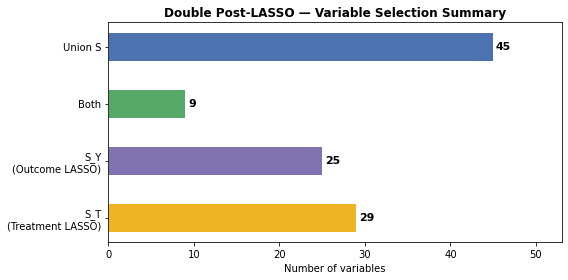

In [116]:
fig, ax = plt.subplots(figsize=(8, 4))
categories = ['S_T\n(Treatment LASSO)', 'S_Y\n(Outcome LASSO)', 'Both', 'Union S']
counts     = [len(selected_T), len(selected_Y), len(both), len(union_selected)]
colors     = ['#F0B323', '#8172B2', '#55A868', '#4C72B0']

bars = ax.barh(categories, counts, color=colors, edgecolor='white', height=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(cnt), va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of variables')
ax.set_title('Double Post-LASSO — Variable Selection Summary', fontweight='bold')
ax.set_xlim(0, max(counts) + 8)
plt.tight_layout()
plt.show()

### Step 4 - Post-LASSO OLS

We regress **Dropout ~ Scholarship + union controls** using OLS with **HC3 heteroskedasticity-robust standard errors**.

The coefficient on `scholarship` is the **Average Treatment Effect (ATE)**: the average change in dropout probability associated with receiving a scholarship, conditional on the selected confounders.

> The LPM is the standard estimator in the Double Post-LASSO framework. It is consistent and its coefficient is directly interpretable as a percentage-point change in probability.

In [117]:
# We create the dataset with the union of covariates
X_union = X_scaled_df[union_selected].copy()
X_union.index = data.index

reg_df = pd.DataFrame({'dropout': Y, 'scholarship': T}, index=data.index).join(X_union)

# Cleaning of the name of the covariates
def sanitize(c):
    return (c.replace(' ', '_').replace('(', '').replace(')', '')
             .replace("'", '').replace('-', '_').replace('/', '_')
             .replace('\t', '').replace('.', ''))

rename_map    = {c: sanitize(c) for c in reg_df.columns}
reg_df        = reg_df.rename(columns=rename_map)
control_cols  = [c for c in reg_df.columns if c not in ['dropout', 'scholarship']]
formula_ols   = 'dropout ~ scholarship + ' + ' + '.join(control_cols)

# ── OLS with robust SE ──────────────────────────────────────────────────────
ols_model = smf.ols(formula_ols, data=reg_df).fit(cov_type='HC3')

ols_coef  = ols_model.params['scholarship']
ols_se    = ols_model.bse['scholarship']
ols_pval  = ols_model.pvalues['scholarship']
ols_ci    = ols_model.conf_int().loc['scholarship']

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                dropout   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     212.5
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:44:11   Log-Likelihood:                -1286.8
No. Observations:                4424   AIC:                             2668.
Df Residuals:                    4377   BIC:                             2968.
Df Model:                          46                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


### Sept 5 - Post-LASSO Logit

The LPM can produce predicted probabilities outside [0, 1]. We verify the result with a **Logit model** on the same union control set.

In [118]:
# ── Logit via statsmodels for proper inference & AME ──────────────────────
formula_logit = formula_ols  # same formula as OLS

for method in ['bfgs', 'lbfgs', 'nm']:
    try:
        logit_model = smf.logit(formula_logit, data=reg_df).fit(
            method=method, maxiter=500, disp=False
        )
        fit_ok = True
        print(f"Logit converged with method='{method}'")
        break
    except Exception as e:
        print(f"method='{method}' failed: {e}")

if not fit_ok:
    raise RuntimeError("Logit failed to converge with all methods. Check for separation or collinearity.")

print(logit_model.summary())

Logit converged with method='bfgs'
                           Logit Regression Results                           
Dep. Variable:                dropout   No. Observations:                 4424
Model:                          Logit   Df Residuals:                     4377
Method:                           MLE   Df Model:                           46
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.4800
Time:                        11:44:11   Log-Likelihood:                -1444.3
converged:                       True   LL-Null:                       -2777.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -1.0486      1.004     -1.044      0.296      -3.016       0.919
scholarship       

In [119]:
# ── Average Marginal Effects ───────────────────────────────────────────────
ame = logit_model.get_margeff()
print(ame.summary())

# Extract scholarship AME
ame_df        = ame.summary_frame()
logit_me      = ame_df.loc['scholarship', 'dy/dx']
logit_me_se   = ame_df.loc['scholarship', 'Std. Err.']
logit_me_pval = ame_df.loc['scholarship', 'Pr(>|z|)']
logit_me_ci   = (ame_df.loc['scholarship', 'Conf. Int. Low'],
                 ame_df.loc['scholarship', 'Cont. Int. Hi.'])

        Logit Marginal Effects       
Dep. Variable:                dropout
Method:                          dydx
At:                           overall
                                          dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
scholarship                             -0.0582      0.014     -4.228      0.000      -0.085      -0.031
Age_at_enrollment                        0.0198      0.008      2.585      0.010       0.005       0.035
Course_9085                             -0.0094      0.005     -1.743      0.081      -0.020       0.001
Mothers_qualification_4                 -0.0150      0.006     -2.543      0.011      -0.027      -0.003
Previous_qualification_grade            -0.0032      0.005     -0.654      0.513      -0.013       0.006
Curricular_units_1st_sem_credited        0.0338      0.015      2.249      0.024       0.004       0.063
Fathers_

### Step 6 - Preliminary Results Summary for Double Post Lasso

In [120]:
print(f"  Treatment  : Scholarship holder")
print(f"  Outcome    : Dropout (binary)")
print(f"  N          : {len(reg_df):,}")
print(f"  Controls   : {len(union_selected)} selected by Double Post-LASSO (union)")
print()
print(f"  ── OLS / Linear Probability Model (HC3 robust SE) ──")
print(f"  ATE         = {ols_coef:+.4f}")
print(f"  Std. Error  = {ols_se:.4f}")
print(f"  p-value     = {ols_pval:.4f}")
print(f"  95% CI      = [{ols_ci[0]:+.4f}, {ols_ci[1]:+.4f}]")
print()
print(f"  ── Logit — Average Marginal Effect ─────────────────")
print(f"  AME         = {logit_me:+.4f}")
print(f"  Std. Error  = {logit_me_se:.4f}")
print(f"  p-value     = {logit_me_pval:.4f}")
print(f"  95% CI      = [{logit_me_ci[0]:+.4f}, {logit_me_ci[1]:+.4f}]")
print()

  Treatment  : Scholarship holder
  Outcome    : Dropout (binary)
  N          : 4,424
  Controls   : 45 selected by Double Post-LASSO (union)

  ── OLS / Linear Probability Model (HC3 robust SE) ──
  ATE         = -0.0502
  Std. Error  = 0.0118
  p-value     = 0.0000
  95% CI      = [-0.0733, -0.0271]

  ── Logit — Average Marginal Effect ─────────────────
  AME         = -0.0582
  Std. Error  = 0.0138
  p-value     = 0.0000
  95% CI      = [-0.0852, -0.0312]



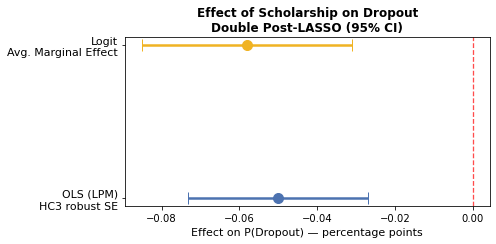

In [121]:
fig, ax = plt.subplots(figsize=(7, 3.5))

estimates = [ols_coef,  logit_me]
errors    = [ols_se,    logit_me_se]
labels    = ['OLS (LPM)\nHC3 robust SE', 'Logit\nAvg. Marginal Effect']
colors    = ['#4C72B0', '#F0B323']

for i, (est, se, label, color) in enumerate(zip(estimates, errors, labels, colors)):
    ax.errorbar(est, i, xerr=se * 1.96, fmt='o', color=color,
                capsize=6, markersize=10, linewidth=2.5)

ax.axvline(0, color='red', linestyle='--', linewidth=1.3, alpha=0.7)
ax.set_yticks([0, 1])
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Effect on P(Dropout) — percentage points', fontsize=11)
ax.set_title('Effect of Scholarship on Dropout\nDouble Post-LASSO (95% CI)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Double Post Lasso with CV
### Step 1 - LASSO of Treatment on Controls

In [122]:
lasso_T = LassoCV(
    cv=5,
    max_iter=10000,
    random_state=42,
    n_alphas=500,
)
lasso_T.fit(X_scaled, T)

print(f'\nOptimal alpha (lambda): {lasso_T.alpha_:.6f}')
print()

coef_T = lasso_T.coef_
selected_T_idx = np.where(coef_T != 0)[0]
selected_T = [feature_names[i] for i in selected_T_idx]

print(f'Selected {len(selected_T)} variables that predict Scholarship:')
for v in selected_T:
    print(f'  • {v}  (coef = {coef_T[feature_names.index(v)]:.4f})')


Optimal alpha (lambda): 0.004920

Selected 101 variables that predict Scholarship:
  • Gender  (coef = -0.0291)
  • Age at enrollment  (coef = -0.0324)
  • Displaced  (coef = -0.0031)
  • Educational special needs  (coef = 0.0008)
  • Previous qualification (grade)  (coef = 0.0112)
  • Curricular units 1st sem (credited)  (coef = -0.0472)
  • Curricular units 2nd sem (credited)  (coef = -0.0142)
  • Curricular units 2nd sem (enrolled)  (coef = -0.0104)
  • Curricular units 1st sem (evaluations)  (coef = -0.0230)
  • Curricular units 2nd sem (evaluations)  (coef = -0.0039)
  • Curricular units 1st sem (approved)  (coef = 0.0330)
  • Curricular units 2nd sem (approved)  (coef = 0.0848)
  • Unemployment rate  (coef = 0.0254)
  • Inflation rate  (coef = -0.0064)
  • GDP  (coef = 0.0088)
  • Marital status_2  (coef = -0.0111)
  • Marital status_4  (coef = 0.0043)
  • Marital status_6  (coef = 0.0003)
  • Mother's qualification_2  (coef = -0.0062)
  • Mother's qualification_3  (coef = -0.03

### Step 2 - LASSO of Outcome on Controls

In [123]:
lasso_Y = LassoCV(
    cv=5,
    max_iter=10000,
    random_state=42,
    n_alphas=500,
)
lasso_Y.fit(X_scaled, Y)

print(f'\nOptimal alpha (lambda): {lasso_Y.alpha_:.6f}')
print()

coef_Y = lasso_Y.coef_
selected_Y_idx = np.where(coef_Y != 0)[0]
selected_Y = [feature_names[i] for i in selected_Y_idx]

print(f'Selected {len(selected_Y)} variables that predict Dropout:')
for v in selected_Y:
    print(f'  • {v}  (coef = {coef_Y[feature_names.index(v)]:.4f})')


Optimal alpha (lambda): 0.005237

Selected 86 variables that predict Dropout:
  • Gender  (coef = 0.0145)
  • Age at enrollment  (coef = 0.0246)
  • Admission grade  (coef = -0.0019)
  • Curricular units 1st sem (credited)  (coef = 0.0288)
  • Curricular units 2nd sem (credited)  (coef = 0.0397)
  • Curricular units 2nd sem (enrolled)  (coef = 0.1624)
  • Curricular units 1st sem (approved)  (coef = -0.0647)
  • Curricular units 2nd sem (approved)  (coef = -0.3051)
  • Curricular units 2nd sem (grade)  (coef = -0.0433)
  • Curricular units 1st sem (without evaluations)  (coef = -0.0038)
  • Curricular units 2nd sem (without evaluations)  (coef = -0.0013)
  • Unemployment rate  (coef = 0.0137)
  • Inflation rate  (coef = -0.0001)
  • Marital status_3  (coef = -0.0042)
  • Marital status_4  (coef = -0.0013)
  • Mother's qualification_2  (coef = -0.0046)
  • Mother's qualification_4  (coef = -0.0066)
  • Mother's qualification_9  (coef = 0.0001)
  • Mother's qualification_11  (coef = 0.0

### Step 3 - Union of selected variables


Variables in S_T only:         66
Variables in S_Y only:         51
Variables in both S_T and S_Y: 35

Total union set size:          152


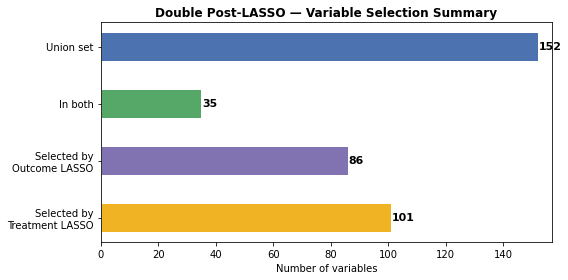

In [124]:
union_selected = list(set(selected_T) | set(selected_Y))

only_T = set(selected_T) - set(selected_Y)
only_Y = set(selected_Y) - set(selected_T)
both   = set(selected_T) & set(selected_Y)

print(f"\nVariables in S_T only:         {len(only_T)}")
print(f"Variables in S_Y only:         {len(only_Y)}")
print(f"Variables in both S_T and S_Y: {len(both)}")
print(f"\nTotal union set size:          {len(union_selected)}")


fig, ax = plt.subplots(figsize=(8, 4))
categories = ['Selected by\nTreatment LASSO', 'Selected by\nOutcome LASSO', 'In both', 'Union set']
counts = [len(selected_T), len(selected_Y), len(both), len(union_selected)]
colors = ['#F0B323', '#8172B2', '#55A868', '#4C72B0']
bars = ax.barh(categories, counts, color=colors, edgecolor='white', height=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of variables')
ax.set_title('Double Post-LASSO — Variable Selection Summary', fontweight='bold')
ax.set_xlim(0, max(counts) + 5)
plt.tight_layout()
plt.show()

### Step 4 - Post-LASSO OLS

The final regression: **Dropout ~ Scholarship + Union controls**

The coefficient on `Scholarship holder` is the **Average Treatment Effect (ATE)** — the average change in probability of dropout when a student receives a scholarship, conditional on the selected confounders.

In [125]:
# We create the dataset with the union of covariates
X_union = X_scaled_df[union_selected].copy()
X_union.index = data.index

reg_df = pd.DataFrame({'dropout': Y, 'scholarship': T}, index=data.index).join(X_union)

# Cleaning of the name of the covariates
def sanitize(c):
    return (c.replace(' ', '_').replace('(', '').replace(')', '')
             .replace("'", '').replace('-', '_').replace('/', '_')
             .replace('\t', '').replace('.', ''))

rename_map    = {c: sanitize(c) for c in reg_df.columns}
reg_df        = reg_df.rename(columns=rename_map)
control_cols  = [c for c in reg_df.columns if c not in ['dropout', 'scholarship']]
formula_ols   = 'dropout ~ scholarship + ' + ' + '.join(control_cols)

# ── OLS with robust SE ──────────────────────────────────────────────────────
ols_model = smf.ols(formula_ols, data=reg_df).fit(cov_type='HC3')

ols_coef_cv  = ols_model.params['scholarship']
ols_se_cv    = ols_model.bse['scholarship']
ols_pval_cv  = ols_model.pvalues['scholarship']
ols_ci_cv    = ols_model.conf_int().loc['scholarship']

print(ols_model.params)

Intercept                               0.334109
scholarship                            -0.051956
Application_mode_18                     0.007906
Fathers_occupation_183                 -0.003323
Fathers_qualification_25                0.006038
                                          ...   
Mothers_qualification_12                0.010397
Curricular_units_1st_sem_evaluations    0.014303
Course_9254                             0.003840
Mothers_occupation_144                 -0.006277
Curricular_units_2nd_sem_evaluations   -0.013012
Length: 154, dtype: float64


## 5. Other models for comparison

### 9.1 Naive OLS vs Post-LASSO OLS

We compare the raw bivariate estimate (no controls) to the Double Post-LASSO estimate to quantify the omitted-variable bias removed by the procedure.

In [126]:
naive_model = smf.ols('dropout ~ scholarship', data=reg_df).fit(cov_type='HC3')
naive_coef  = naive_model.params['scholarship']
naive_se    = naive_model.bse['scholarship']
naive_pval  = naive_model.pvalues['scholarship']


print(f"  Naive OLS (no controls)   : β = {naive_coef:+.4f}  SE={naive_se:.4f}  p={naive_pval:.4f}")
print(f"  Post-LASSO OLS            : β = {ols_coef:+.4f}  SE={ols_se:.4f}  p={ols_pval:.4f}")
print(f"  Post-LASSO OLS CV         : β = {ols_coef_cv:+.4f}")

  Naive OLS (no controls)   : β = -0.2651  SE=0.0130  p=0.0000
  Post-LASSO OLS            : β = -0.0502  SE=0.0118  p=0.0000
  Post-LASSO OLS CV         : β = -0.0520


### 9.2 Controlling for Mediators (misspecified model)

By including `Debtor` and `Tuition fees up to date` as controls, we demonstrate the **post-treatment bias** that arises when mediators are incorrectly added to the regression. The shift in the scholarship coefficient relative to the correct specification quantifies how much of the scholarship effect operates through financial constraints.

In [127]:
mediators           = ['Debtor', 'Tuition fees up to date']
available_mediators = [m for m in mediators if m in df.columns]

reg_df_med = reg_df.copy()
for m in available_mediators:
    safe = sanitize(m)
    reg_df_med[safe] = df.loc[data.index, m].values

formula_med = formula_ols + ' + ' + ' + '.join([sanitize(m) for m in available_mediators])
model_med   = smf.ols(formula_med, data=reg_df_med).fit(cov_type='HC3')
coef_med    = model_med.params['scholarship']

print(f"  Correct (no mediators) : β = {ols_coef:+.4f}")
print(f"  With mediators         : β = {coef_med:+.4f}")

  Correct (no mediators) : β = -0.0502
  With mediators         : β = -0.0442


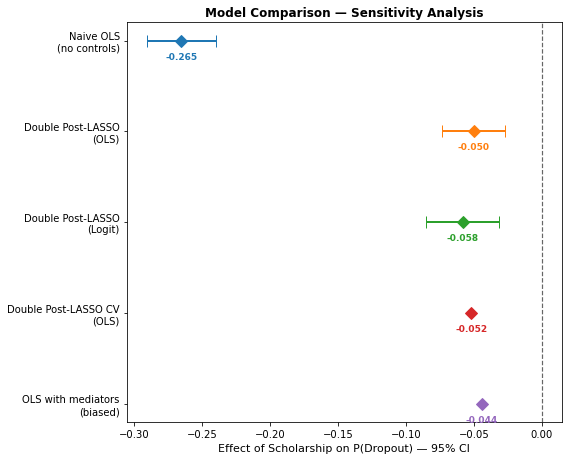

In [128]:
# ── Comparison plot ──────────────────────────────────────────────────────

models_comparison = {
    'Naive OLS\n(no controls)': (float(naive_coef), float(naive_se)),
    'Double Post-LASSO\n(OLS)': (float(ols_coef), float(ols_se)),
    'Double Post-LASSO\n(Logit)': (float(logit_me), float(logit_me_se)),
    'Double Post-LASSO CV\n(OLS)': (float(ols_coef_cv), float(ols_se_cv))
}

if available_mediators:
    models_comparison["OLS with mediators\n(biased)"] = (
        float(coef_med),
        float(model_med.bse['scholarship'])
    )

# Figure
fig, ax = plt.subplots(figsize=(8, 1 + len(models_comparison) * 1.1))

# Robust palette (unlimited models)
palette = plt.cm.tab10.colors

# Plot
for i, (label, values) in enumerate(models_comparison.items()):
    
    est, se = values
    color = palette[i % len(palette)]
    
    ax.errorbar(
        est,
        i,
        xerr=1.96 * se,
        fmt='D',
        color=color,
        capsize=6,
        markersize=9,
        linewidth=2
    )
    
    ax.text(
        est,
        i + 0.20,
        f'{est:+.3f}',
        ha='center',
        fontsize=9,
        color=color,
        fontweight='bold'
    )

# Reference line
ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.6
)

# Axis formatting
ax.set_yticks(range(len(models_comparison)))
ax.set_yticklabels(models_comparison.keys(), fontsize=10)

ax.set_xlabel(
    'Effect of Scholarship on P(Dropout) — 95% CI',
    fontsize=11
)

ax.set_title(
    'Model Comparison — Sensitivity Analysis',
    fontweight='bold'
)

# Standard in causal inference plots
ax.invert_yaxis()

plt.tight_layout()
plt.show()